## Train / validation / test split and baselines

I split the matches chronologically first, then I build a few simple baselines.
The baselines are useful because the machine-learning models shouldd be compared with something simple.

In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    f1_score, 
    precision_score, 
    recall_score
)

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (PROCESSED_DATA_DIR / "featured_matches_2015_2025.csv")

matches = pd.read_csv(
    input_file, 
    parse_dates = ["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print("First date:", matches["Date"]. min())
print("Last date:", matches["Date"].max())

Dataset shape: (26536, 48)
First date: 2015-01-05 00:00:00
Last date: 2025-11-16 00:00:00


In [3]:
## did the target remain balanced even after feature engineering?
print(
    matches["Player1Won"].value_counts(normalize=True).sort_index()
)

Player1Won
0    0.502487
1    0.497513
Name: proportion, dtype: float64


A random split would mix old and future matches, so I use a chronological split:

- training: 2015-2022
- validation: 2023
- test: 2024-2025

The test set stays untouched until the final notebook.

In [4]:
validation_start = pd.Timestamp("2023-01-01")
test_start = pd.Timestamp("2024-01-01")

In [5]:
train_data = matches.loc[
    matches["Date"] < validation_start
].copy()

validation_data = matches.loc[
    (matches["Date"] >= validation_start) & 
    (matches["Date"] < test_start)
].copy()

test_data = matches.loc[
    matches["Date"] >= test_start
].copy()

In [6]:
split_summary = pd.DataFrame(
    {
        "Split": [
            "Training", 
            "Validation", 
            "Test"
        ],
        "NumberOfMatches": [
            len(train_data),
            len(validation_data), 
            len(test_data)
        ],
        "FirstDate": [
            train_data["Date"].min(), 
            validation_data["Date"].min(), 
            test_data["Date"].min()
        ],
        "LastDate": [
            train_data["Date"].max(),
            validation_data["Date"].max(),
            test_data["Date"].max()
        ], 
        "Player1WinProportion": [
            train_data["Player1Won"].mean(), 
            validation_data["Player1Won"].mean(), 
            test_data["Player1Won"].mean()
        ]
    }
)

split_summary

,Split,NumberOfMatches,FirstDate,LastDate,Player1WinProportion
0,Training,18810,2015-01-05,2022-11-20,0.498458
1,Validation,2607,2023-01-01,2023-12-31,0.475259
2,Test,5119,2024-01-01,2025-11-16,0.505372


In [7]:
assert train_data["Date"].max() < validation_data["Date"].min()
assert validation_data["Date"].max() < test_data["Date"].min()

assert (
    len(train_data)+len(validation_data)+len(test_data)
    == len(matches)
)

print("Chronological split validation passed.")

Chronological split validation passed.


In [8]:
 ## add split label
 ## the select function receives a list of condition 
 ## and a list of corresponding values. 
matches["DataSplit"] = np.select(
    [
        matches["Date"] < validation_start, 
        (
            (matches["Date"] >= validation_start)
            & (matches["Date"] < test_start)
        ), 
        matches["Date"] >= test_start
    ], 
    [
        "Training", 
        "Validation", 
        "Test"
    ], 
    default="Unknown"
)

In [9]:
print(matches["DataSplit"].value_counts())

assert matches["DataSplit"].ne("Unknown").all()

print("Every match received a split label.")

DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64
Every match received a split label.


In [10]:
target_column = "Player1Won"

y_train = train_data[target_column] ## correct results of training matches
y_validation = validation_data[target_column] ## correct results of validation matches 
y_test = test_data[target_column] ## correct results of the test matches

In [11]:
## decide the columns that can be used as model inputs 

excluded_columns = [
    "MatchID", 
    "Date", ## not needed bc there are other attributes
    "SourceYear", ## only identifies the source file 
    "ATP",
    "Location", ## contain many categories --> make the model too complicated
    "Tournament",## same as Location
    "Player1", ## better to avoid names, the model may memorize players
    "Player2", 
    "Player1Won", # answer we are predicted, cannot be included 
    "DataSplit"
    
]

## separate main features 

numeric_features = [
    "Player1Rank",
    "Player2Rank",
    "Player1Points",
    "Player2Points", 
    
    "Player1MatchesBefore", 
    "Player2MatchesBefore", 
    "ExperienceDifference", 
    
    "Player1WinRateBefore",
    "Player2WinRateBefore", 
    "WinRateDifference", 
    
    "Player1Recent5WinRate",
    "Player2Recent5WinRate",
    "Recent5WinRateDifference",
    
    "Player1SurfaceMatchesBefore",
    "Player2SurfaceMatchesBefore",
    
    "Player1SurfaceWinRateBefore",
    "Player2SurfaceWinRateBefore",
    "SurfaceWinRateDifference",
    
    "H2HMatchesBefore",
    "Player1H2HWinRateBefore",
    "Player2H2HWinRateBefore",
    "DifferenceH2HWinRateBefore",
    
    "Player1DaysSinceLastMatch",
    "Player2DaysSinceLastMatch",
    
    "RankDifference",
    "PointsDifference"
]

categorical_features = [
    "Series", 
    "Court", 
    "Surface", 
    "Round", 
    "Best of"
]

## The first models use only the numerical features.
## The categorical columns are kept as a possible extension.
main_features = numeric_features

## check that all the columns exist
missing_model_columns = [
    column
    for column in main_features
    if column not in matches.columns
]

print("Missing model columns:", missing_model_columns)


Missing model columns: []


In [12]:
## Optional betting features.
## They are pre-match information, but I keep them out of the main experiment
## so that the model is based mainly on the tennis features created above.

betting_features = [
    "Player1B365Odds",
    "Player2B365Odds",
    "Player1PSOdds",
    "Player2PSOdds",
    "Player1MaxOdds",
    "Player2MaxOdds",
    "Player1AvgOdds",
    "Player2AvgOdds"
]

In [13]:
X_train = train_data[main_features].copy()

X_validation = validation_data[main_features].copy()

X_test = test_data[main_features].copy()

In [14]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print( "X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)


X_train shape: (18810, 26)
y_train shape: (18810,)
X_validation shape: (2607, 26)
y_validation shape: (2607,)
X_test shape (5119, 26)
y_test shape (5119,)


In [15]:
assert len(X_train) == len(y_train)

assert len(X_validation) == len(y_validation)

assert len(X_test) == len(y_test)

print("Feature and target dimensions are consistent.")

Feature and target dimensions are consistent.


In [16]:
training_missing_values = (
    X_train.isna().sum().sort_values(ascending=False)
)

training_missing_values[
    training_missing_values > 0 
]

Player2DaysSinceLastMatch    328
Player1DaysSinceLastMatch    317
dtype: int64

In [17]:
def evaluate_predictions (
    y_true, # contains real match results
    y_pred, # contains predicted match results
    model_name
):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred), 
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division = 0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }
    
    return pd.DataFrame([results])

In [18]:
## define the baseline using majority voting 

majority_class = y_train.mode().iloc[0] ## mode returns the most freq value
print("Majority training class:", majority_class)

Majority training class: 0


In [19]:
majority_predictions = np.full( # full creates an array where every value is identical
    shape = len(validation_data),
    fill_value = majority_class
)

In [20]:
majority_results = evaluate_predictions(
    y_true = y_validation, 
    y_pred = majority_predictions, 
    model_name = "Majority class"
)

majority_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Majority class,0.524741,0.5,0.0,0.0,0.0


In [21]:
## define baseline using better-ranked player

ranking_predictions = np.where(
    validation_data["RankDifference"] > 0, 
    1, ## predict 1 when player1 is better ranked
    0
)

equal_rank = (
    validation_data["RankDifference"] == 0
)

ranking_predictions[equal_rank] = np.where(
    validation_data.loc[
        equal_rank, 
        "PointsDifference"
    ] >= 0, 
    1, # predict player1 when player1 has at least as many points
    0
)

ranking_results = evaluate_predictions (
    y_true = y_validation, 
    y_pred = ranking_predictions, 
    model_name = "Better-ranked player"
)

ranking_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Better-ranked player,0.640199,0.640648,0.614973,0.649718,0.631868


In [22]:
## baseline based on ranking points

points_predictions = np.where(
    validation_data["PointsDifference"] >= 0, 
    1, # when player1 has more points than player2
    0
)

points_results = evaluate_predictions(
    y_true = y_validation, 
    y_pred = points_predictions, 
    model_name = "More ranking points"
)

points_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,More ranking points,0.626007,0.626592,0.600152,0.638418,0.618694


In [23]:
## baseline using historical win rate

win_rate_predictions = np.where(
    validation_data["WinRateDifference"] >= 0, 
    1, ## player1 has an eq or greater prev win rate
    0
)

win_rate_results = evaluate_predictions(
    y_true = y_validation, 
    y_pred = win_rate_predictions,
    model_name = "Higher previous win rate"
)

win_rate_results 

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Higher previous win rate,0.607979,0.608424,0.582635,0.617433,0.59953


In [24]:
## baseline based on the recent win rate 

recent_form_predictions = np.where(
    validation_data["Recent5WinRateDifference"]>= 0,
    1,
    0
)

recent_form_results = evaluate_predictions(
    y_true = y_validation, 
    y_pred = recent_form_predictions, 
    model_name = "Better recent win rate"
)

recent_form_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Better recent win rate,0.549674,0.557169,0.519219,0.708636,0.599317


In [25]:
## combine all baseline results 

baseline_results = pd.concat(
    [
        majority_results, 
        ranking_results, 
        points_results, 
        win_rate_results, 
        recent_form_results
    ],
    ignore_index = True
)

baseline_results = baseline_results.sort_values(
    by= "Accuracy", 
    ascending= False
).reset_index(drop=True)

baseline_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Better-ranked player,0.640199,0.640648,0.614973,0.649718,0.631868
1,More ranking points,0.626007,0.626592,0.600152,0.638418,0.618694
2,Higher previous win rate,0.607979,0.608424,0.582635,0.617433,0.599530
3,Better recent win rate,0.549674,0.557169,0.519219,0.708636,0.599317
4,Majority class,0.524741,0.500000,0.000000,0.000000,0.000000


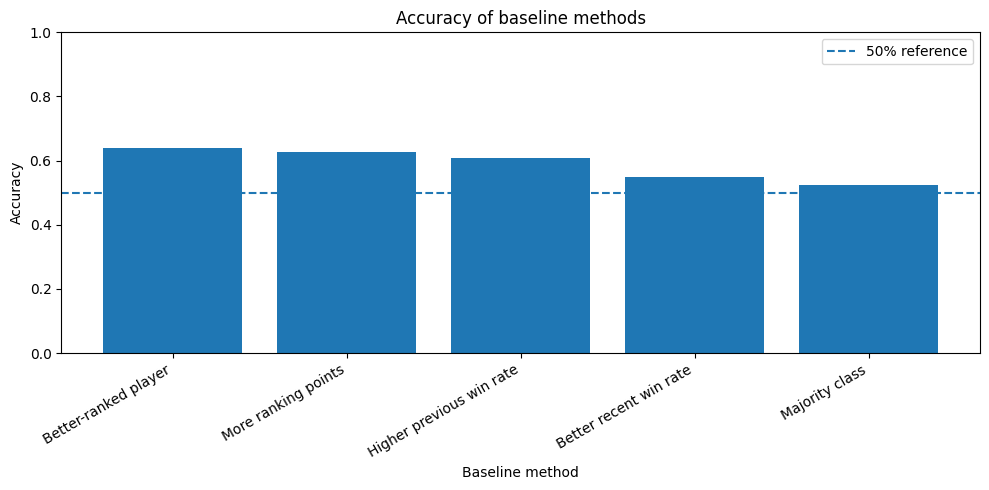

In [26]:
## create a baseline accuracy graph 

plt.figure(figsize =(10, 5))

plt.bar( ## to create a bar char 
    baseline_results["Model"],
    baseline_results["Accuracy"]
)

plt.axhline(  # draws an horizontal ref line at 50% accuracy
    y=0.5, 
    linestyle = "--",
    label = "50% reference"
)

plt.title("Accuracy of baseline methods")

plt.xlabel("Baseline method")
plt.ylabel("Accuracy")

plt.ylim(0, 1) ## vertical axis accuracy range

plt.xticks(
    rotation = 30, 
    ha= "right"
)

plt.legend()
plt.tight_layout() # prevent labels from being cut off
plt.show()

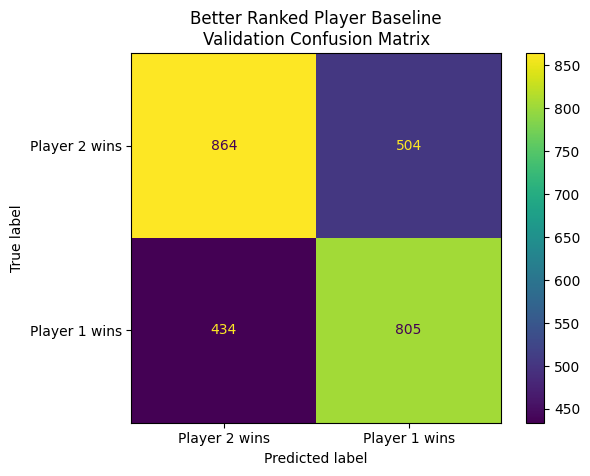

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_validation, 
    ranking_predictions, 
    display_labels=[
        "Player 2 wins",
        "Player 1 wins"
    ],
    values_format = "d"
)

plt.title(
    "Better Ranked Player Baseline\n"
    "Validation Confusion Matrix"
)

plt.show()

Our previous result table reports precision and recall considering:

Player1Won = 1

as the positive class.

The classification report allows you to verify whether prediction quality is similar for Player 1 and Player 2.

In [28]:
print(
    classification_report( 
        y_validation,
        ranking_predictions,
        target_names=[
            "Player 2 wins",
            "Player 1 wins"
        ],
        zero_division = 0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.67      0.63      0.65      1368
Player 1 wins       0.61      0.65      0.63      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



In [29]:
## copy of the validation matches 
validation_analysis = validation_data[
    [
        "MatchID",
        "Date",
        "Tournament",
        "Surface",
        "Round",
        "Player1",
        "Player2",
        "Player1Rank",
        "Player2Rank",
        "RankDifference",
        "Player1Won"
    ]
].copy()

## add prediction as feature
validation_analysis["RankingPrediction"] = ranking_predictions

## add a column to tell if prediction was correct
validation_analysis["PredictionCorrect"] = (
    validation_analysis["Player1Won"] ==
    validation_analysis["RankingPrediction"]
)

##check the proportion 
validation_analysis["PredictionCorrect"].value_counts(normalize=True)

## display incorrect predictions 
validation_analysis.loc[
    ~validation_analysis["PredictionCorrect"]
].head(20)
## these are the matches where the worse-ranked player won
    

,MatchID,Date,Tournament,Surface,Round,Player1,Player2,Player1Rank,Player2Rank,RankDifference,Player1Won,RankingPrediction,PredictionCorrect
18814,18814,2023-01-02,Adelaide International 1,Hard,1st Round,Cressy M.,Kokkinakis T.,34.0,93.0,59.0,0,1,False
18815,18815,2023-01-02,Adelaide International 1,Hard,1st Round,Rune H.,Nishioka Y.,11.0,36.0,25.0,0,1,False
18816,18816,2023-01-02,Adelaide International 1,Hard,1st Round,Auger-Aliassime F.,Popyrin A.,6.0,120.0,114.0,0,1,False
18817,18817,2023-01-02,Adelaide International 1,Hard,1st Round,Safiullin R.,Ymer M.,88.0,69.0,-19.0,1,0,False
18819,18819,2023-01-02,Maharashtra Open,Hard,1st Round,Zapata Miralles B.,Carballes Baena R.,72.0,74.0,2.0,0,1,False
18820,18820,2023-01-02,Maharashtra Open,Hard,1st Round,Cecchinato M.,Basilashvili N.,101.0,91.0,-10.0,1,0,False
18821,18821,2023-01-02,Maharashtra Open,Hard,1st Round,Molcan A.,Djere L.,50.0,70.0,20.0,0,1,False
18822,18822,2023-01-02,Maharashtra Open,Hard,1st Round,Munar J.,Griekspoor T.,58.0,95.0,37.0,0,1,False
18824,18824,2023-01-03,Adelaide International 1,Hard,1st Round,Bautista Agut R.,Rublev A.,21.0,8.0,-13.0,1,0,False
18832,18832,2023-01-03,Maharashtra Open,Hard,1st Round,Ymer E.,Marterer M.,127.0,159.0,32.0,0,1,False


In [30]:
# compare ranking difference for correct and wrong predictions

validation_analysis.groupby("PredictionCorrect")["RankDifference"].describe()

validation_analysis[
    "AbsoluteRankDifference"
    ] = validation_analysis[
        "RankDifference"
        ].abs()
    
validation_analysis.groupby(
    "PredictionCorrect"
)["AbsoluteRankDifference"].describe()

,count,mean,std,min,25%,50%,75%,max
PredictionCorrect,,,,,,,,
False,938.0,60.113006,87.269098,1.0,16.0,37.0,69.0,930.0
True,1669.0,113.931096,264.692948,1.0,23.0,48.0,95.0,4911.0


In [31]:
## save split dataset

split_output_file = (
    PROCESSED_DATA_DIR / "feature_split_matches.csv"
)

matches.to_csv(split_output_file, index = False)

print(
    "Split dataset saved to:",
    split_output_file.resolve()
)

Split dataset saved to: /mnt/data/artificial_intelligence_reviewed/data/processed/feature_split_matches.csv


In [32]:
baseline_output_file = (
    PROCESSED_DATA_DIR / "validation_baseline.csv"
)

baseline_results.to_csv(
    baseline_output_file, 
    index = False
)

print(
    "Baseline results saved to:",
    baseline_output_file.resolve()
)

Baseline results saved to: /mnt/data/artificial_intelligence_reviewed/data/processed/validation_baseline.csv


In [33]:
print("Training matches:", len(train_data))
print("Validation matches:", len(validation_data))
print("Test matches:", len(test_data))

print("\nValidation baseline results: ")
print(baseline_results)

print("\nBest validation baseline:")
print(baseline_results.iloc[0])

Training matches: 18810
Validation matches: 2607
Test matches: 5119

Validation baseline results: 
                      Model  Accuracy  ...    Recall        F1
0      Better-ranked player  0.640199  ...  0.649718  0.631868
1       More ranking points  0.626007  ...  0.638418  0.618694
2  Higher previous win rate  0.607979  ...  0.617433  0.599530
3    Better recent win rate  0.549674  ...  0.708636  0.599317
4            Majority class  0.524741  ...  0.000000  0.000000

[5 rows x 6 columns]

Best validation baseline:
Model               Better-ranked player
Accuracy                        0.640199
BalancedAccuracy                0.640648
Precision                       0.614973
Recall                          0.649718
F1                              0.631868
Name: 0, dtype: object


In [34]:
## final summary
print(split_summary)

print(
    baseline_results[
        [
            "Model",
            "Accuracy",
            "BalancedAccuracy",
            "Precision",
            "Recall",
            "F1"
        ]
    ]
)

print(
    validation_analysis.groupby(
        "PredictionCorrect"
    )["AbsoluteRankDifference"].describe()
)

        Split  NumberOfMatches  FirstDate   LastDate  Player1WinProportion
0    Training            18810 2015-01-05 2022-11-20              0.498458
1  Validation             2607 2023-01-01 2023-12-31              0.475259
2        Test             5119 2024-01-01 2025-11-16              0.505372
                      Model  Accuracy  ...    Recall        F1
0      Better-ranked player  0.640199  ...  0.649718  0.631868
1       More ranking points  0.626007  ...  0.638418  0.618694
2  Higher previous win rate  0.607979  ...  0.617433  0.599530
3    Better recent win rate  0.549674  ...  0.708636  0.599317
4            Majority class  0.524741  ...  0.000000  0.000000

[5 rows x 6 columns]
                    count        mean         std  ...   50%   75%     max
PredictionCorrect                                  ...                    
False               938.0   60.113006   87.269098  ...  37.0  69.0   930.0
True               1669.0  113.931096  264.692948  ...  48.0  95.0  4911.0
